## Downloading the Data

In [2]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [3]:
from urllib.request import urlretrieve
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x1d599eaecd0>)

## Load Data and Import heder files

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib
import plotly.express as px

%matplotlib inline

In [5]:
medical_df = pd.read_csv("medical.csv")
medical_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [9]:
fig = px.histogram(medical_df, 
                   x='age', 
                   marginal='box', 
                   nbins=47, 
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [10]:
fig = px.histogram(medical_df, 
                   x='bmi', 
                   marginal='box', 
                   color_discrete_sequence=['red'], 
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

In [11]:
fig = px.histogram(medical_df, 
                   x='charges', 
                   marginal='box', 
                   color='smoker', 
                   color_discrete_sequence=['green', 'grey'], 
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [12]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [13]:
px.histogram(medical_df, x='smoker', color='sex', title='Smoker')

In [14]:
fig = px.scatter(medical_df, 
                 x='age', 
                 y='charges', 
                 color='smoker', 
                 opacity=0.8, 
                 hover_data=['sex'], 
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [15]:
fig = px.scatter(medical_df, 
                 x='bmi', 
                 y='charges', 
                 color='smoker', 
                 opacity=0.8, 
                 hover_data=['sex'], 
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [16]:
catgorical_cols = medical_df.select_dtypes(include='object').columns.to_list()
numerical_cols = medical_df.select_dtypes(include=np.number).columns.tolist()

numerical_data = medical_df[numerical_cols]
catgorical_data = medical_df[catgorical_cols]
numerical_data

C:\Users\nigam\AppData\Local\Temp\ipykernel_180\1710250728.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catgorical_cols = medical_df.select_dtypes(include='object').columns.to_list()


,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


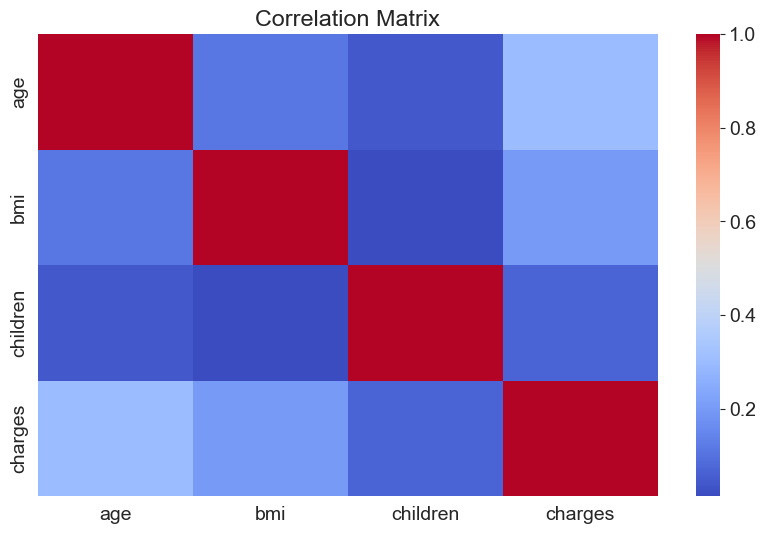

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(numerical_data.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [18]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984782)

In [19]:
numerical_data.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [20]:
input_data = medical_df.drop("charges",axis=1)
target_data = medical_df["charges"]
target_data

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit(catgorical_data)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_categ

In [22]:
encoder.categories_

[array(['female', 'male'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [23]:
encoded_cols = list(encoder.get_feature_names_out(catgorical_cols))
print(encoded_cols)

['sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [24]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [25]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()

In [28]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape :', inputs.shape)
print('targes.shape :', targets.shape)

inputs.shape : (1064, 1)
targes.shape : (1064,)


In [29]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
model.predict(np.array([[23], 
                        [37], 
                        [61]]))

c:\Users\nigam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [31]:
predictions = model.predict(inputs)

In [32]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [33]:
# w
model.coef_

array([267.24891283])

In [34]:
# b
model.intercept_

np.float64(-2091.4205565650864)

In [35]:
def estimate_charges(age, w, b):
    return w * age + b

In [36]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)
    
    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);
    
    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  8461.949562575493


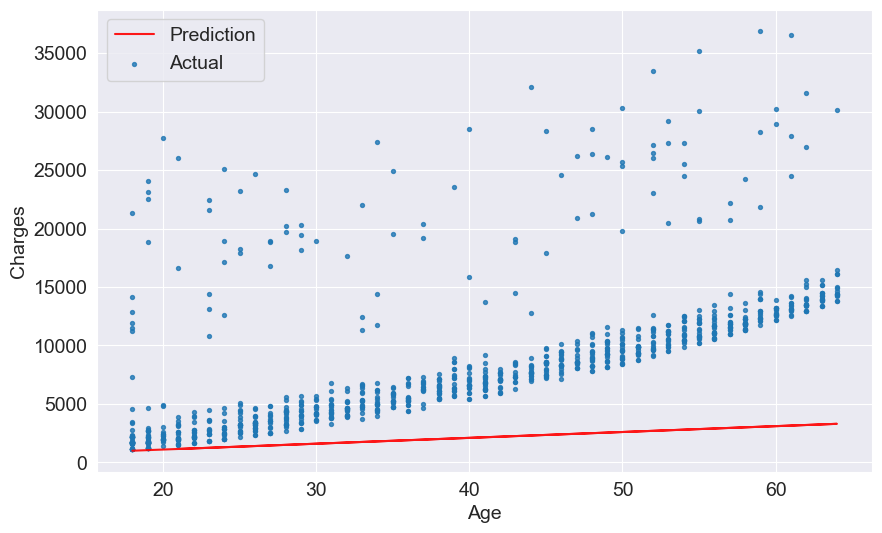

In [37]:
try_parameters(50, 100)

RMSE Loss:  4662.505766636395


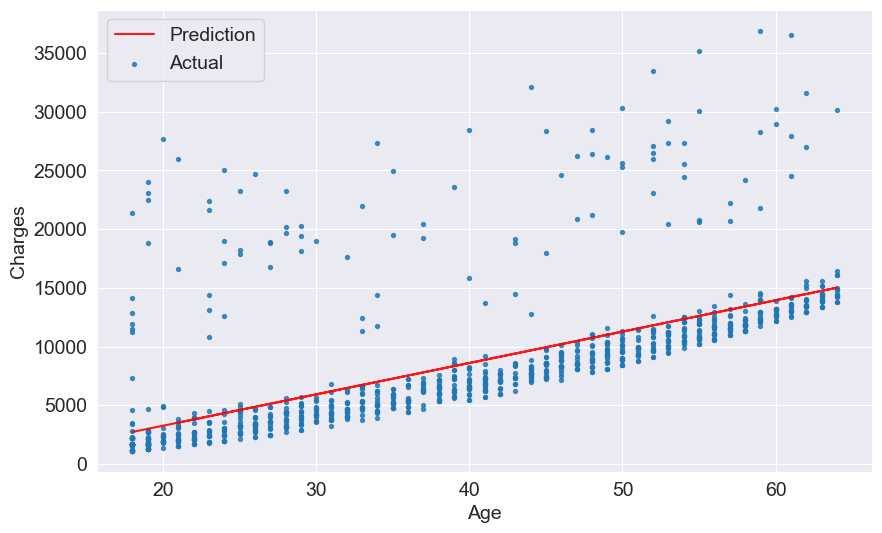

In [38]:
try_parameters(model.coef_, model.intercept_)

In [39]:
data = pd.read_csv("medical.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [43]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), str(1)
memory usage: 73.3 KB


In [40]:
data["sex"] = data["sex"].map({"female":0,"male":1})
data["smoker"] = data["smoker"].map({"yes":1,"no":0})
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [41]:
x = data.drop(columns=["charges"])
y = data["charges"]
print(x)
print(y)

      age  sex     bmi  children  smoker     region
0      19    0  27.900         0       1  southwest
1      18    1  33.770         1       0  southeast
2      28    1  33.000         3       0  southeast
3      33    1  22.705         0       0  northwest
4      32    1  28.880         0       0  northwest
...   ...  ...     ...       ...     ...        ...
1333   50    1  30.970         3       0  northwest
1334   18    0  31.920         0       0  northeast
1335   18    0  36.850         0       0  southeast
1336   21    0  25.800         0       0  southwest
1337   61    0  29.070         0       1  northwest

[1338 rows x 6 columns]
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [42]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 6)
(268, 6)
(1070,)
(268,)


In [47]:
numarical_cols = x_train.select_dtypes(include=["int64","float64"]).columns
catgorical_cols = x_train.select_dtypes(include="object").columns
print(numarical_cols)
print(catgorical_cols)

Index(['age', 'sex', 'bmi', 'children', 'smoker'], dtype='str')
Index(['region'], dtype='str')


C:\Users\nigam\AppData\Local\Temp\ipykernel_180\2370704344.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catgorical_cols = x_train.select_dtypes(include="object").columns


In [48]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder

scaler = StandardScaler()
x_train_num = scaler.fit_transform(x_train[numarical_cols])
x_test_num = scaler.transform(x_test[numarical_cols])

encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
x_train_cat = encoder.fit_transform(x_train[catgorical_cols])
x_test_cat = encoder.transform(x_test[catgorical_cols])

x_train_final = np.hstack([x_train_num,x_train_cat])
x_test_final = np.hstack([x_test_num,x_test_cat])

x_train_final


array([[ 0.47222651, -1.0246016 , -1.75652513, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.54331294, -1.0246016 , -1.03308239, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.8987451 , -1.0246016 , -0.94368672, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.3252637 ,  0.97598911, -0.89153925, ...,  0.        ,
         0.        ,  0.        ],
       [-0.16755139, -1.0246016 ,  2.82086429, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.1120044 ,  0.97598911, -0.10932713, ...,  0.        ,
         0.        ,  1.        ]], shape=(1070, 9))

In [49]:
from sklearn.metrics import r2_score,root_mean_squared_error

from sklearn.linear_model import (
    LinearRegression,Ridge,Lasso,ElasticNet,
    BayesianRidge,ARDRegression,SGDRegressor,
    PassiveAggressiveRegressor,HuberRegressor,
    RANSACRegressor,TheilSenRegressor
)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "BayesianRidge": BayesianRidge(),
    "ARDRegression": ARDRegression(),
    "SGDRegressor": SGDRegressor(max_iter=1000),
    "PassiveAggressive": PassiveAggressiveRegressor(max_iter=1000),
    "Huber": HuberRegressor(),
    "RANSAC": RANSACRegressor(),
    "TheilSen": TheilSenRegressor()
}

results = []

for name,model in models.items():
    try:
        model.fit(x_train_final,y_train)
        y_pred = model.predict(x_test_final)
        
        r2 = r2_score(y_test,y_pred)
        rmse = root_mean_squared_error(y_test,y_pred)
        
        results.append((name,r2,rmse))
    except Exception as e:
        print("f{name} failed : {e}")
        
results_df = pd.DataFrame(results,columns=["Model","r2-score","RMSE"])
results_df = results_df.sort_values(by="RMSE",ascending=False)

print(results_df)            

c:\Users\nigam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


                Model  r2-score         RMSE
9              RANSAC  0.676751  7084.071430
3          ElasticNet  0.683406  7010.760987
7   PassiveAggressive  0.721440  6576.171576
8               Huber  0.724688  6537.718358
10           TheilSen  0.759210  6114.110275
5       ARDRegression  0.781681  5821.840274
6        SGDRegressor  0.783411  5798.726880
4       BayesianRidge  0.783438  5798.361905
1               Ridge  0.783538  5797.026639
2               Lasso  0.783547  5796.904799
0    LinearRegression  0.783593  5796.284659


In [50]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1)

model.fit(x_train_final,y_train)

y_pred = model.predict(x_test_final)

r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print(f"Random Foreste Regressor R2-Score:{r2} and RMSE:{rmse}")

Random Foreste Regressor R2-Score:0.8631793401601349 and RMSE:4608.821311572677


In [51]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200,max_depth=50,random_state=42,n_jobs=-1)

model.fit(x_train_final,y_train)

y_pred = model.predict(x_test_final)

r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print(f"Random Foreste Regressor R2-Score:{r2} and RMSE:{rmse}")

Random Foreste Regressor R2-Score:0.8641589044200367 and RMSE:4592.29330217943


In [55]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=210,max_depth=50,random_state=42,n_jobs=-1)

model.fit(x_train_final,y_train)

y_pred = model.predict(x_test_final)

r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print(f"Random Foreste Regressor R2-Score:{r2} and RMSE:{rmse}")

Random Foreste Regressor R2-Score:0.8641600942387523 and RMSE:4592.273190414064


## RandomForestRegressor performs best  with
            (n_estimators=210,
            max_depth=50,
            random_state=42,
            n_jobs=-1)